In [4]:
!pip install gdown

import gdown, zipfile, os

# 🔥 PASTE YOUR LINK HERE (ANY format)
url = "https://drive.google.com/file/d/1doUhVoq1-c9pamZVLpvjW1YRDMkKO1Q5/view?usp=drive_link"

# This handles all link types automatically
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)

# Extract
with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files in data:", os.listdir("data"))

Downloading...
From (original): https://drive.google.com/uc?id=1doUhVoq1-c9pamZVLpvjW1YRDMkKO1Q5
From (redirected): https://drive.google.com/uc?id=1doUhVoq1-c9pamZVLpvjW1YRDMkKO1Q5&confirm=t&uuid=b77308f4-2d71-43cd-bc46-a016e8f5dfa4
To: /content/dataset.zip
100%|██████████| 2.11G/2.11G [01:25<00:00, 24.6MB/s]


Files in data: ['train_lenses', 'test_lenses', '__MACOSX', 'test_nonlenses', 'train_nonlenses']


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [6]:
class LensDataset(Dataset):
    def __init__(self, lens_dir, nonlens_dir):
        self.images = []
        self.labels = []

        # label 1 = lens
        for file in os.listdir(lens_dir):
            if file.endswith(".npy"):
                self.images.append(os.path.join(lens_dir, file))
                self.labels.append(1)

        # label 0 = non-lens
        for file in os.listdir(nonlens_dir):
            if file.endswith(".npy"):
                self.images.append(os.path.join(nonlens_dir, file))
                self.labels.append(0)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = np.load(self.images[idx])
        img = torch.tensor(img, dtype=torch.float32)

        # ensure (C,H,W)
        if len(img.shape) == 2:
            img = img.unsqueeze(0)

        return img, self.labels[idx]

In [7]:
train_dataset = LensDataset(
    "data/train_lenses",
    "data/train_nonlenses"
)

test_dataset = LensDataset(
    "data/test_lenses",
    "data/test_nonlenses"
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 30405
Test: 19650


In [8]:
labels = train_dataset.labels

num_lens = sum(labels)
num_nonlens = len(labels) - num_lens

print("Lens:", num_lens, "Non-lens:", num_nonlens)

weight = num_nonlens / num_lens
class_weights = torch.tensor([1.0, weight])

Lens: 1730 Non-lens: 28675


In [9]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),  # dataset has 3 channels
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4,4))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*4*4, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 357.5544528439641
Epoch 2, Loss: 308.8623633272946
Epoch 3, Loss: 290.6240259036422
Epoch 4, Loss: 273.2897509075701
Epoch 5, Loss: 271.69661956094205


In [11]:
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:,1].cpu().numpy()

        y_scores.extend(probs)
        y_true.extend(labels.numpy())

auc = roc_auc_score(y_true, y_scores)
print("AUC Score:", auc)

AUC Score: 0.9464128264436668


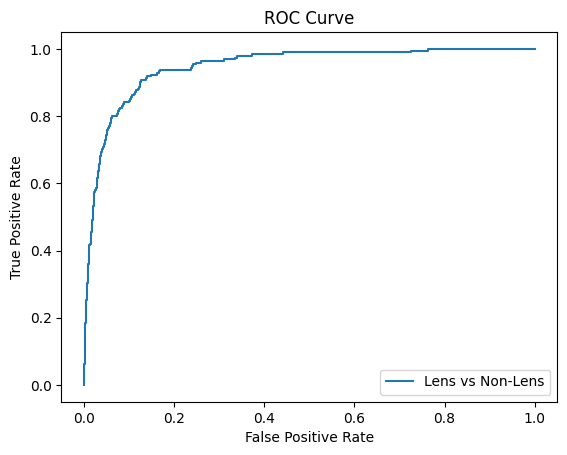

In [12]:
fpr, tpr, _ = roc_curve(y_true, y_scores)

plt.plot(fpr, tpr, label="Lens vs Non-Lens")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()